# 🍽️ Food Detection, Segmentation & Nutrition Analyser v3

## Why this version is different
The previous version used **YOLOv8 trained on COCO** (80 general classes: bowl, dining table, person…).  
That is why it kept predicting "bowl" or "dining table" instead of the actual food.

This notebook trains YOLOv8 **from scratch on Food-101** (101 food categories).  
After training, inference only ever predicts real food names — no more bowls or tables.

## Full pipeline
| Step | Cell | What it does |
|------|------|--------------|
| Setup | 1–2 | Install packages, configure |
| Data | 3 | Download Food-101 & convert to YOLO format |
| Train | 4 | Fine-tune YOLOv8n on Food-101 |
| Detect | 5–6 | Upload image → run trained model |
| Review | 7 | Interactive widget: fix wrong labels, enter grams |
| Output | 8–9 | Annotated image + calorie table |

## Notes on liquids
YOLO is an object detector — it needs a visible region to segment.  
For liquids (juice, soup, tea, coffee) the model will detect the **container region**.  
The interactive widget in Cell 7 lets you rename it to the correct drink and enter the ml/grams.

## Cell 1 — Install Dependencies

In [1]:
!pip install ultralytics pillow pandas requests ipywidgets scipy --quiet
print('✅ All packages installed')

✅ All packages installed


## Cell 2 — Imports & Configuration

In [2]:
import io, os, json, shutil, colorsys, random, textwrap
import requests
import numpy as np
import torch
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, clear_output
import ipywidgets as widgets

# ─── GPU DIAGNOSTICS ──────────────────────────────────────────────────────────
print('=== GPU / CUDA Status ===')
print(f'PyTorch version   : {torch.__version__}')
print(f'CUDA available    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA version      : {torch.version.cuda}')
    print(f'GPU count         : {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}           : {props.name}')
        print(f'  VRAM            : {props.total_memory / 1024**3:.1f} GB')
        print(f'  Compute cap.    : {props.major}.{props.minor}')
else:
    print('  ⚠️  No CUDA GPU detected.')
    print('  → Make sure NVIDIA drivers + CUDA toolkit are installed.')
    print('  → Run: nvidia-smi  in a terminal to verify your GPU is visible.')
print('==========================')

# ─── CONFIG ───────────────────────────────────────────────────────────────────
# Training
EPOCHS          = 30        # Increase to 50-100 for better accuracy
IMGSZ           = 640       # Input resolution for training and inference
BATCH           = 32        # Increased from 16 — GPU can handle more; reduce if OOM
TRAIN_RATIO     = 0.80      # 80% train, 20% val
FOOD101_CLASSES = 101       # all 101 categories
WORKERS         = 8         # DataLoader workers — good for i9-14900 (24 cores)

# Paths
DATA_DIR        = Path('food101_yolo')   # prepared YOLO dataset
MODEL_OUT_DIR   = Path('runs/food_seg') # where trained weights land
BEST_WEIGHTS    = MODEL_OUT_DIR / 'weights/best.pt'

# Inference
CONF_THRESHOLD  = 0.35      # below this → ask user to confirm/correct

# USDA nutrition API
USDA_API_KEY    = 'DEMO_KEY'
USDA_API_URL    = 'https://api.nal.usda.gov/fdc/v1/foods/search'

# ─── Device selection ─────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
    HALF   = True    # FP16 — faster on modern NVIDIA GPUs
    # Pin GPU 0 explicitly (change index if you have multiple GPUs)
    torch.cuda.set_device(0)
    # Warm up CUDA context now so first training step isn't slow
    _ = torch.zeros(1).cuda()
    print(f'\n✅ Config ready  |  device=cuda ({torch.cuda.get_device_name(0)})  |  half-precision=True')
else:
    DEVICE = 'cpu'
    HALF   = False
    print(f'\n✅ Config ready  |  device=cpu  |  half-precision=False')
    print('   ⚠️  Training on CPU is very slow. Install CUDA drivers for GPU acceleration.')


=== GPU / CUDA Status ===
PyTorch version   : 2.5.1+cu121
CUDA available    : True
CUDA version      : 12.1
GPU count         : 1
  GPU 0           : NVIDIA GeForce RTX 4090
  VRAM            : 24.0 GB
  Compute cap.    : 8.9

✅ Config ready  |  device=cuda (NVIDIA GeForce RTX 4090)  |  half-precision=True


## Cell 3 — Download Food-101 & Convert to YOLO Format

> ⏱ First run: downloads ~5 GB via **torchvision** (Windows-compatible, handles verification automatically).  
> Subsequent runs are instant — already extracted.
>
> Food-101 provides **classification labels only** (no bounding boxes).  
> We generate a **whole-image bounding box** for each photo so YOLO can train.  
> After training you get proper food-class segmentation on real meal images.

In [3]:
import subprocess, sys, tarfile, json, random, shutil
from pathlib import Path

# ── Install torchvision (already in most PyTorch envs) ───────────────────────
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torchvision', '--quiet'])

import torchvision
from torchvision.datasets import Food101
from PIL import Image as PILImage

FOOD101_ROOT = Path('food-101-torchvision')   # torchvision stores data here
DATA_DIR     = Path('food101_yolo')            # YOLO-format output

# ── 1. Download via torchvision (works on Windows, handles verify + extract) ──
print('Downloading Food-101 via torchvision (~5 GB)…')
print('First run takes a while; subsequent runs are instant (already extracted).')

ds_train = Food101(root=str(FOOD101_ROOT), split='train', download=True)
ds_test  = Food101(root=str(FOOD101_ROOT), split='test',  download=True)
print(f'✅ Download complete  |  train={len(ds_train)}  val={len(ds_test)}')

# ── 2. Build class list ───────────────────────────────────────────────────────
CLASSES = ds_train.classes   # list of 101 strings
print(f'✅ {len(CLASSES)} food classes loaded')

# Write classes.txt so any downstream code that reads it still works
META = FOOD101_ROOT / 'food-101' / 'meta'
META.mkdir(parents=True, exist_ok=True)
(META / 'classes.txt').write_text('\n'.join(CLASSES) + '\n')

# ── 3. Convert to YOLO format (whole-image bbox) ──────────────────────────────
if DATA_DIR.exists():
    print(f'✅ YOLO dataset already exists at {DATA_DIR}, skipping conversion')
else:
    TRAIN_PER_CLASS = 200
    VAL_PER_CLASS   = 50
    print(f'Converting to YOLO format ({TRAIN_PER_CLASS} train / {VAL_PER_CLASS} val per class)…')

    def export_split(dataset, split_name, per_class):
        img_out = DATA_DIR / split_name / 'images'
        lbl_out = DATA_DIR / split_name / 'labels'
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        counts = {}
        total  = 0

        for img, cls_idx in dataset:
            if counts.get(cls_idx, 0) >= per_class:
                continue
            stem    = f'{CLASSES[cls_idx]}__{counts.get(cls_idx, 0):04d}'
            dst_img = img_out / f'{stem}.jpg'
            dst_lbl = lbl_out / f'{stem}.txt'

            # img is already a PIL Image from torchvision
            img.convert('RGB').save(dst_img, format='JPEG', quality=90)
            # YOLO label: class cx cy w h (whole image = 0.5 0.5 1.0 1.0)
            dst_lbl.write_text(f'{cls_idx} 0.5 0.5 1.0 1.0\n')

            counts[cls_idx] = counts.get(cls_idx, 0) + 1
            total += 1
            if total % 2000 == 0:
                print(f'  {split_name}: {total} images written…', end='\r')

        print(f'  {split_name}: done ({total} images)          ')

    export_split(ds_train, 'train', TRAIN_PER_CLASS)
    export_split(ds_test,  'val',   VAL_PER_CLASS)

    # Write dataset YAML
    try:
        import yaml
        yaml_content = {
            'path' : str(DATA_DIR.resolve()),
            'train': 'train/images',
            'val'  : 'val/images',
            'nc'   : len(CLASSES),
            'names': list(CLASSES),
        }
        with open(DATA_DIR / 'food101.yaml', 'w') as yf:
            yaml.dump(yaml_content, yf, default_flow_style=False, allow_unicode=True)
    except ImportError:
        lines = (
            [f'path: {DATA_DIR.resolve()}', 'train: train/images', 'val: val/images',
             f'nc: {len(CLASSES)}', 'names:']
            + [f'  - {c}' for c in CLASSES]
        )
        (DATA_DIR / 'food101.yaml').write_text('\n'.join(lines))

    print(f'\n✅ Dataset ready at {DATA_DIR}')

DATASET_YAML = str(DATA_DIR / 'food101.yaml')
print(f'Dataset YAML: {DATASET_YAML}')


First run takes a while; subsequent runs are instant (already extracted).
✅ Download complete  |  train=75750  val=25250
✅ 101 food classes loaded
✅ YOLO dataset already exists at food101_yolo, skipping conversion
Dataset YAML: food101_yolo\food101.yaml


In [7]:
import json, shutil, random
from pathlib import Path
import torchvision
from torchvision.datasets import Food101

FOOD101_ROOT = Path('food-101-torchvision')
DATA_DIR     = Path('food101_yolo')

# Reload dataset objects to get class list
ds_test  = Food101(root=str(FOOD101_ROOT), split='test', download=False)
CLASSES  = ds_test.classes

# ── Create val folder if missing ──────────────────────────────────────────────
val_img = DATA_DIR / 'val' / 'images'
val_lbl = DATA_DIR / 'val' / 'labels'

if val_img.exists():
    print(f'✅ Val already exists ({len(list(val_img.glob("*.jpg")))} images)')
else:
    val_img.mkdir(parents=True, exist_ok=True)
    val_lbl.mkdir(parents=True, exist_ok=True)
    
    VAL_PER_CLASS = 50
    counts = {}
    total  = 0
    
    for img, cls_idx in ds_test:
        if counts.get(cls_idx, 0) >= VAL_PER_CLASS:
            continue
        stem = f'{CLASSES[cls_idx]}__{counts.get(cls_idx, 0):04d}'
        img.convert('RGB').save(val_img / f'{stem}.jpg', format='JPEG', quality=90)
        (val_lbl / f'{stem}.txt').write_text(f'{cls_idx} 0.5 0.5 1.0 1.0\n')
        counts[cls_idx] = counts.get(cls_idx, 0) + 1
        total += 1
        if total % 1000 == 0:
            print(f'  {total} val images written…', end='\r')
    
    print(f'✅ Val split created — {total} images')

# ── Rewrite YAML with absolute path (fixes Windows path issues) ───────────────
yaml_path = DATA_DIR / 'food101.yaml'
lines = [
    f'path: {DATA_DIR.resolve()}',
    'train: train/images',
    'val:   val/images',
    f'nc: {len(CLASSES)}',
    'names:',
] + [f'  - {c}' for c in CLASSES]
yaml_path.write_text('\n'.join(lines))
print(f'✅ YAML written → {yaml_path}')

# Update DATASET_YAML for Cell 4
DATASET_YAML = str(yaml_path.resolve())
print(f'✅ DATASET_YAML = {DATASET_YAML}')

✅ Val split created — 5050 images
✅ YAML written → food101_yolo\food101.yaml
✅ DATASET_YAML = C:\Users\Student2\Downloads\food101_yolo\food101.yaml


## Cell 4 — Train YOLOv8 on Food-101

> ⏱ Training time (subsampled dataset, 30 epochs):
> - GPU (T4/A100): ~15–40 min  
> - CPU only: 4–8 hours (not recommended — use Google Colab GPU)
>
> To skip training and use a previously trained model, set `SKIP_TRAINING = True` and update `BEST_WEIGHTS`.

In [8]:
from ultralytics import YOLO

SKIP_TRAINING = False   # Set True to load existing weights and skip training

if SKIP_TRAINING and BEST_WEIGHTS.exists():
    print(f'✅ Skipping training — loading weights from {BEST_WEIGHTS}')
    model = YOLO(str(BEST_WEIGHTS))
elif BEST_WEIGHTS.exists():
    print(f'✅ Trained weights found at {BEST_WEIGHTS} — loading (skip training)')
    model = YOLO(str(BEST_WEIGHTS))
else:
    print('🚀 Starting training…')
    if DEVICE == 'cuda':
        print(f'   GPU: {torch.cuda.get_device_name(0)}')
        print(f'   VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
        print(f'   Batch size: {BATCH}  |  Workers: {WORKERS}  |  FP16: {HALF}')
    else:
        print('   ⚠️  Running on CPU — consider using a GPU for faster training')

    model = YOLO('yolov8n.pt')   # ~6 MB, auto-downloaded

    results_train = model.train(
        data     = DATASET_YAML,
        epochs   = EPOCHS,
        imgsz    = IMGSZ,
        batch    = BATCH,
        project  = str(MODEL_OUT_DIR.parent),
        name     = MODEL_OUT_DIR.name,
        device   = DEVICE,
        half     = HALF,
        workers  = WORKERS,          # parallel data loading — uses your 24 CPU cores
        cache    = 'ram',            # cache dataset in RAM — you have 128 GB, use it!
        patience = 10,
        exist_ok = True,
        verbose  = False,
        # AMP (Automatic Mixed Precision) is enabled automatically when half=True
        # This halves VRAM usage and speeds up training by ~2x on modern GPUs
    )
    print(f'\n✅ Training complete — best weights at {BEST_WEIGHTS}')
    model = YOLO(str(BEST_WEIGHTS))

print(f'✅ Model ready  |  classes: {model.names[0]}…{model.names[100]}')


🚀 Starting training…
   GPU: NVIDIA GeForce RTX 4090
   VRAM available: 24.0 GB
   Batch size: 32  |  Workers: 8  |  FP16: True
New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.9.25 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Student2\Downloads\food101_yolo\food101.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=True, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=N

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\food_seg\\weights\\best.pt'

In [9]:
import glob
from pathlib import Path

# Search for best.pt anywhere under runs/
found = list(Path('.').rglob('best.pt'))
print("Found best.pt at:")
for f in found:
    print(f"  {f.resolve()}")

# Also show the runs folder structure
for p in sorted(Path('runs').rglob('*.pt')):
    print(p.resolve())

Found best.pt at:
  C:\Users\Student2\Downloads\runs\detect\runs\food_seg\weights\best.pt
C:\Users\Student2\Downloads\runs\detect\runs\food_seg\weights\best.pt
C:\Users\Student2\Downloads\runs\detect\runs\food_seg\weights\last.pt


In [10]:
from ultralytics import YOLO

# Replace this with whatever path printed above
BEST_WEIGHTS = Path(found[0])  # auto-uses the first result found

model = YOLO(str(BEST_WEIGHTS))
print(f'✅ Model loaded from {BEST_WEIGHTS}')
print(f'✅ Classes: {model.names[0]} … {model.names[100]}')

✅ Model loaded from runs\detect\runs\food_seg\weights\best.pt
✅ Classes: apple_pie … waffles


## Cell 4b — Nutrition Database & Drawing Helpers

In [11]:
# ── Built-in nutrition table (kcal / protein g / carbs g / fat g per 100g/ml) ─
# Covers all 101 Food-101 categories plus common liquids
BUILTIN = {
    # ── Food-101 categories ───────────────────────────────────────────────────
    'apple_pie':              {'calories':237,'protein':2.0,'carbs':34.0,'fat':11.0},
    'baby_back_ribs':         {'calories':295,'protein':19.0,'carbs':11.0,'fat':19.0},
    'baklava':                {'calories':428,'protein':6.0,'carbs':46.0,'fat':25.0},
    'beef_carpaccio':         {'calories':160,'protein':19.0,'carbs':0.0,'fat':9.0},
    'beef_tartare':           {'calories':193,'protein':20.0,'carbs':2.0,'fat':11.0},
    'beet_salad':             {'calories':75,'protein':2.0,'carbs':12.0,'fat':3.0},
    'beignets':               {'calories':320,'protein':5.0,'carbs':43.0,'fat':14.0},
    'bibimbap':               {'calories':147,'protein':8.0,'carbs':22.0,'fat':3.0},
    'bread_pudding':          {'calories':210,'protein':6.0,'carbs':35.0,'fat':6.0},
    'breakfast_burrito':      {'calories':250,'protein':13.0,'carbs':26.0,'fat':10.0},
    'bruschetta':             {'calories':180,'protein':5.0,'carbs':24.0,'fat':7.0},
    'caesar_salad':           {'calories':120,'protein':5.0,'carbs':8.0,'fat':8.0},
    'cannoli':                {'calories':356,'protein':7.0,'carbs':37.0,'fat':19.0},
    'caprese_salad':          {'calories':170,'protein':9.0,'carbs':4.0,'fat':13.0},
    'carrot_cake':            {'calories':415,'protein':4.0,'carbs':56.0,'fat':20.0},
    'ceviche':                {'calories':90,'protein':15.0,'carbs':5.0,'fat':2.0},
    'cheese_plate':           {'calories':380,'protein':22.0,'carbs':2.0,'fat':31.0},
    'cheesecake':             {'calories':321,'protein':5.5,'carbs':26.0,'fat':22.0},
    'chicken_curry':          {'calories':150,'protein':14.0,'carbs':8.0,'fat':7.0},
    'chicken_quesadilla':     {'calories':282,'protein':18.0,'carbs':22.0,'fat':12.0},
    'chicken_wings':          {'calories':290,'protein':27.0,'carbs':0.0,'fat':19.0},
    'chocolate_cake':         {'calories':371,'protein':5.0,'carbs':50.0,'fat':17.0},
    'chocolate_mousse':       {'calories':274,'protein':5.0,'carbs':25.0,'fat':18.0},
    'churros':                {'calories':370,'protein':5.0,'carbs':48.0,'fat':18.0},
    'clam_chowder':           {'calories':110,'protein':6.0,'carbs':12.0,'fat':4.5},
    'club_sandwich':          {'calories':320,'protein':22.0,'carbs':28.0,'fat':13.0},
    'crab_cakes':             {'calories':197,'protein':14.0,'carbs':10.0,'fat':11.0},
    'creme_brulee':           {'calories':225,'protein':4.0,'carbs':26.0,'fat':12.0},
    'croque_madame':          {'calories':380,'protein':22.0,'carbs':24.0,'fat':21.0},
    'cup_cakes':              {'calories':396,'protein':4.0,'carbs':54.0,'fat':18.0},
    'deviled_eggs':           {'calories':163,'protein':7.0,'carbs':1.0,'fat':14.0},
    'donuts':                 {'calories':452,'protein':5.0,'carbs':51.0,'fat':25.0},
    'dumplings':              {'calories':185,'protein':7.0,'carbs':27.0,'fat':5.0},
    'edamame':                {'calories':122,'protein':11.0,'carbs':10.0,'fat':5.0},
    'eggs_benedict':          {'calories':266,'protein':14.0,'carbs':15.0,'fat':16.0},
    'escargots':              {'calories':90,'protein':16.0,'carbs':2.0,'fat':1.4},
    'falafel':                {'calories':333,'protein':13.0,'carbs':31.0,'fat':18.0},
    'filet_mignon':           {'calories':227,'protein':26.0,'carbs':0.0,'fat':13.0},
    'fish_and_chips':         {'calories':280,'protein':12.0,'carbs':30.0,'fat':12.0},
    'foie_gras':              {'calories':462,'protein':11.0,'carbs':5.0,'fat':44.0},
    'french_fries':           {'calories':312,'protein':3.4,'carbs':41.0,'fat':15.0},
    'french_onion_soup':      {'calories':112,'protein':5.0,'carbs':14.0,'fat':4.0},
    'french_toast':           {'calories':230,'protein':8.0,'carbs':28.0,'fat':9.0},
    'fried_calamari':         {'calories':175,'protein':12.0,'carbs':15.0,'fat':7.0},
    'fried_rice':             {'calories':163,'protein':4.0,'carbs':28.0,'fat':4.0},
    'frozen_yogurt':          {'calories':127,'protein':3.0,'carbs':22.0,'fat':3.5},
    'garlic_bread':           {'calories':350,'protein':8.0,'carbs':45.0,'fat':15.0},
    'gnocchi':                {'calories':130,'protein':3.0,'carbs':25.0,'fat':2.0},
    'greek_salad':            {'calories':80,'protein':2.0,'carbs':7.0,'fat':5.0},
    'grilled_cheese_sandwich':{'calories':350,'protein':14.0,'carbs':29.0,'fat':19.0},
    'grilled_salmon':         {'calories':208,'protein':20.0,'carbs':0.0,'fat':13.0},
    'guacamole':              {'calories':150,'protein':2.0,'carbs':9.0,'fat':13.0},
    'gyoza':                  {'calories':190,'protein':8.0,'carbs':24.0,'fat':7.0},
    'hamburger':              {'calories':295,'protein':17.0,'carbs':24.0,'fat':14.0},
    'hot_and_sour_soup':      {'calories':60,'protein':4.0,'carbs':8.0,'fat':1.5},
    'hot_dog':                {'calories':290,'protein':11.0,'carbs':2.0,'fat':26.0},
    'huevos_rancheros':       {'calories':270,'protein':14.0,'carbs':22.0,'fat':13.0},
    'hummus':                 {'calories':166,'protein':8.0,'carbs':14.0,'fat':10.0},
    'ice_cream':              {'calories':207,'protein':3.5,'carbs':24.0,'fat':11.0},
    'lasagna':                {'calories':166,'protein':11.0,'carbs':15.0,'fat':7.0},
    'lobster_bisque':         {'calories':104,'protein':6.0,'carbs':10.0,'fat':4.0},
    'lobster_roll_sandwich':  {'calories':360,'protein':18.0,'carbs':36.0,'fat':15.0},
    'macaroni_and_cheese':    {'calories':310,'protein':12.0,'carbs':40.0,'fat':11.0},
    'macarons':               {'calories':420,'protein':4.0,'carbs':67.0,'fat':14.0},
    'miso_soup':              {'calories':40,'protein':3.0,'carbs':5.0,'fat':1.0},
    'mussels':                {'calories':86,'protein':12.0,'carbs':4.0,'fat':2.3},
    'nachos':                 {'calories':345,'protein':8.0,'carbs':44.0,'fat':16.0},
    'omelette':               {'calories':154,'protein':11.0,'carbs':0.5,'fat':12.0},
    'onion_rings':            {'calories':411,'protein':5.0,'carbs':38.0,'fat':27.0},
    'oysters':                {'calories':69,'protein':7.0,'carbs':4.0,'fat':2.5},
    'pad_thai':               {'calories':223,'protein':8.0,'carbs':32.0,'fat':7.0},
    'paella':                 {'calories':218,'protein':13.0,'carbs':28.0,'fat':5.0},
    'pancakes':               {'calories':227,'protein':6.0,'carbs':35.0,'fat':7.0},
    'panna_cotta':            {'calories':145,'protein':3.0,'carbs':17.0,'fat':7.5},
    'peking_duck':            {'calories':337,'protein':19.0,'carbs':0.0,'fat':29.0},
    'pho':                    {'calories':90,'protein':7.0,'carbs':12.0,'fat':1.5},
    'pizza':                  {'calories':266,'protein':11.0,'carbs':33.0,'fat':10.0},
    'pork_chop':              {'calories':231,'protein':26.0,'carbs':0.0,'fat':14.0},
    'poutine':                {'calories':330,'protein':9.0,'carbs':36.0,'fat':17.0},
    'prime_rib':              {'calories':302,'protein':25.0,'carbs':0.0,'fat':22.0},
    'pulled_pork_sandwich':   {'calories':280,'protein':20.0,'carbs':24.0,'fat':10.0},
    'ramen':                  {'calories':152,'protein':8.0,'carbs':22.0,'fat':3.5},
    'ravioli':                {'calories':220,'protein':10.0,'carbs':30.0,'fat':6.0},
    'red_velvet_cake':        {'calories':399,'protein':4.0,'carbs':56.0,'fat':18.0},
    'risotto':                {'calories':166,'protein':5.0,'carbs':28.0,'fat':3.5},
    'samosa':                 {'calories':308,'protein':6.0,'carbs':35.0,'fat':16.0},
    'sashimi':                {'calories':130,'protein':20.0,'carbs':0.0,'fat':5.0},
    'scallops':               {'calories':111,'protein':20.0,'carbs':5.0,'fat':1.0},
    'seaweed_salad':          {'calories':45,'protein':2.0,'carbs':7.0,'fat':1.0},
    'shrimp_and_grits':       {'calories':230,'protein':14.0,'carbs':22.0,'fat':9.0},
    'spaghetti_bolognese':    {'calories':230,'protein':14.0,'carbs':23.0,'fat':8.0},
    'spaghetti_carbonara':    {'calories':340,'protein':14.0,'carbs':30.0,'fat':17.0},
    'spring_rolls':           {'calories':193,'protein':5.0,'carbs':24.0,'fat':8.0},
    'steak':                  {'calories':271,'protein':26.0,'carbs':0.0,'fat':18.0},
    'strawberry_shortcake':   {'calories':280,'protein':4.0,'carbs':40.0,'fat':12.0},
    'sushi':                  {'calories':150,'protein':6.0,'carbs':28.0,'fat':1.5},
    'tacos':                  {'calories':226,'protein':11.0,'carbs':19.0,'fat':11.0},
    'takoyaki':               {'calories':188,'protein':7.0,'carbs':22.0,'fat':8.0},
    'tiramisu':               {'calories':240,'protein':5.0,'carbs':29.0,'fat':11.0},
    'tuna_tartare':           {'calories':180,'protein':22.0,'carbs':3.0,'fat':9.0},
    'waffles':                {'calories':291,'protein':8.0,'carbs':37.0,'fat':12.0},
    # ── Common liquids (per 100ml treated as 100g) ───────────────────────────
    'coffee':                 {'calories':2,'protein':0.3,'carbs':0.0,'fat':0.0},
    'tea':                    {'calories':1,'protein':0.0,'carbs':0.3,'fat':0.0},
    'milk':                   {'calories':61,'protein':3.2,'carbs':4.8,'fat':3.3},
    'orange juice':           {'calories':45,'protein':0.7,'carbs':10.4,'fat':0.2},
    'cola':                   {'calories':42,'protein':0.0,'carbs':10.6,'fat':0.0},
    'beer':                   {'calories':43,'protein':0.5,'carbs':3.6,'fat':0.0},
    'wine':                   {'calories':83,'protein':0.1,'carbs':2.7,'fat':0.0},
    'smoothie':               {'calories':80,'protein':1.5,'carbs':17.0,'fat':0.5},
    'lemonade':               {'calories':40,'protein':0.1,'carbs':10.0,'fat':0.1},
    'soup':                   {'calories':50,'protein':2.5,'carbs':7.0,'fat':1.5},
}

_cache = {}

def get_nutrition(food_name: str) -> dict:
    key = food_name.lower().strip()
    if key in _cache:
        return _cache[key]
    # 1. exact match
    if key in BUILTIN:
        _cache[key] = BUILTIN[key]; return BUILTIN[key]
    # 2. substring match
    for bk, bv in BUILTIN.items():
        if bk in key or key in bk:
            _cache[key] = bv; return bv
    # 3. USDA fallback
    try:
        r = requests.get(USDA_API_URL,
                         params={'query': food_name, 'api_key': USDA_API_KEY},
                         timeout=5)
        data = r.json()
        if data.get('foods'):
            nuts = data['foods'][0]['foodNutrients']
            def fn(nid):
                for n in nuts:
                    if n.get('nutrientId') == nid: return round(n['value'],1)
                return None
            res = {'calories':fn(208),'protein':fn(203),'carbs':fn(205),'fat':fn(204)}
            _cache[key] = res; return res
    except Exception:
        pass
    res = {'calories':None,'protein':None,'carbs':None,'fat':None}
    _cache[key] = res; return res


def kcal(per100, grams):
    if per100 is None or not grams: return None
    return round(per100 * grams / 100, 1)


def gen_colors(n):
    out = []
    for i in range(max(n,1)):
        r,g,b = colorsys.hsv_to_rgb(i/max(n,1), 0.80, 0.95)
        out.append((int(r*255),int(g*255),int(b*255)))
    return out


def draw_output(original_image, segments, nutrition_results):
    img     = original_image.convert('RGBA')
    overlay = Image.new('RGBA', img.size, (0,0,0,0))
    dov     = ImageDraw.Draw(overlay)
    colors  = gen_colors(len(segments))

    try:
        fB = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 18)
        fP = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 16)
        fS = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 14)
    except IOError:
        fB = fP = fS = ImageFont.load_default()

    color_map = {}
    for idx, seg in enumerate(segments):
        r,g,b  = colors[idx % len(colors)]
        lbl    = seg['label']
        poly   = seg.get('polygon')
        color_map[lbl] = (r,g,b)

        if poly and len(poly) >= 3:
            dov.polygon(poly, fill=(r,g,b,90), outline=(r,g,b,230))
            xs=[p[0] for p in poly]; ys=[p[1] for p in poly]
            lx,ly = min(xs), max(0,min(ys)-26)
        else:
            bx = seg.get('box',(0,0,80,40))
            dov.rectangle(bx, fill=(r,g,b,70), outline=(r,g,b,230), width=3)
            lx,ly = bx[0], max(0,bx[1]-26)

        gs  = f" {seg['grams']}g" if seg.get('grams') else ''
        txt = f"{lbl.replace('_',' ')} ({seg['confidence']:.0%}){gs}"
        bb  = dov.textbbox((lx,ly), txt, font=fB)
        dov.rectangle([bb[0]-4,bb[1]-2,bb[2]+4,bb[3]+2], fill=(r,g,b,220))
        dov.text((lx,ly), txt, fill=(255,255,255,255), font=fB)

    ann = Image.alpha_composite(img, overlay).convert('RGB')

    # calorie panel
    merged={}
    for seg in segments:
        merged[seg['label']] = merged.get(seg['label'],0) + (seg.get('grams') or 0)

    ROW=34; PAD=20; HDR=50; FTR=54
    W   = ann.width
    ph  = HDR + len(merged)*ROW + FTR + PAD*2
    panel = Image.new('RGB',(W,ph),(18,18,24))
    dp    = ImageDraw.Draw(panel)
    dp.rectangle([0,0,W,HDR],fill=(28,28,38))
    dp.text((PAD,14),'🍽  Nutritional Breakdown (by actual weight)',fill=(220,220,240),font=fP)

    cx=[PAD,W-440,W-320,W-210,W-110]
    for x,h in zip(cx,['Food','Weight','Calories','Protein','Carbs']):
        dp.text((x,HDR+8),h,fill=(140,140,180),font=fS)
    dp.line([(PAD,HDR+28),(W-PAD,HDR+28)],fill=(60,60,80),width=1)

    total=0.0; y0=HDR+36
    def f(v,u=''): return f'{v:.1f}{u}' if v is not None else '?'

    for i,(lbl,grams) in enumerate(merged.items()):
        y    = y0+i*ROW
        info = nutrition_results.get(lbl,{})
        dp.rectangle([0,y,W,y+ROW-2],fill=(24,24,32) if i%2==0 else (30,30,42))
        sc=color_map.get(lbl,(120,120,120))
        dp.rectangle([PAD,y+9,PAD+12,y+ROW-9],fill=sc)
        cv=kcal(info.get('calories'),grams)
        pv=kcal(info.get('protein'), grams)
        qv=kcal(info.get('carbs'),   grams)
        if cv: total+=cv
        for x,t in zip(cx,[lbl.replace('_',' ').title(),
                            f'{grams}g' if grams else '?',
                            f(cv,' kcal'), f(pv,'g'), f(qv,'g')]):
            dp.text((x,y+9),t,fill=(210,210,230),font=fS)

    fy=y0+len(merged)*ROW+10
    dp.line([(PAD,fy-4),(W-PAD,fy-4)],fill=(80,80,120),width=1)
    dp.text((PAD,fy+6),f'Total Estimated Calories:  {total:.1f} kcal',
            fill=(255,210,100),font=fP)

    final=Image.new('RGB',(W,ann.height+ph))
    final.paste(ann,(0,0)); final.paste(panel,(0,ann.height))
    return final


print('✅ Nutrition DB and drawing helpers ready')

✅ Nutrition DB and drawing helpers ready


## Cell 5 — Upload Your Food Photo

In [30]:
uploader   = widgets.FileUpload(accept='image/*', multiple=False, description='📷 Upload')
IMAGE_PATH = r"C:\Users\Student2\Downloads\4fd171cd0e53d4e13bbcd713af1d5607.jpg"   # alternative: set a local path, e.g. 'plate.jpg'
display(uploader)

FileUpload(value=(), accept='image/*', description='📷 Upload')

## Cell 6 — Run Detection

The trained model now only predicts **food classes** — no more "dining table" or "bowl".

For **liquids**: YOLO will detect the liquid region (e.g. a cup or glass area).  
In Cell 7 you can rename it to the correct drink (e.g. `coffee`, `orange juice`) and the calorie lookup will use the liquid table.

In [34]:
# ── Load image ────────────────────────────────────────────────────────────────
if uploader.value:
    name = list(uploader.value.keys())[0]
    image = Image.open(io.BytesIO(bytes(uploader.value[name]['content']))).convert('RGB')
    print(f'✅ {name}  {image.size}')
elif IMAGE_PATH and os.path.exists(IMAGE_PATH):
    image = Image.open(IMAGE_PATH).convert('RGB')
    print(f'✅ {IMAGE_PATH}  {image.size}')
else:
    raise FileNotFoundError('Upload an image above or set IMAGE_PATH.')

# ── Inference ─────────────────────────────────────────────────────────────────
results = model(
    image,
    imgsz  = IMGSZ,
    conf   = 0.20,    # low — we handle uncertain ones in the widget
    iou    = 0.45,
    half   = HALF,
    verbose= False,
)

segments     = []
uncertain    = []

for result in results:
    for i, box in enumerate(result.boxes):
        lbl  = result.names[int(box.cls)]
        conf = float(box.conf)
        x1,y1,x2,y2 = map(int, box.xyxy[0])

        poly = None
        if result.masks is not None and i < len(result.masks.xy):
            poly = [tuple(p) for p in result.masks.xy[i].astype(int)]

        seg = dict(label=lbl, original_label=lbl, confidence=conf,
                   box=(x1,y1,x2,y2), polygon=poly, grams=None)

        if conf < CONF_THRESHOLD:
            uncertain.append(seg)
        else:
            segments.append(seg)

print(f'✅ Done')
print(f'   High confidence ({len(segments)}): {[s["label"] for s in segments]}')
print(f'   Uncertain       ({len(uncertain)}): {[s["label"] for s in uncertain]}')

if not segments and not uncertain:
    print('\n⚠️  Nothing detected. Run Cell 7 to add food items manually.')
else:
    print('\n👉 Run Cell 7 to review, rename, and enter gram weights.')

✅ C:\Users\Student2\Downloads\4fd171cd0e53d4e13bbcd713af1d5607.jpg  (1200, 1200)
✅ Done
   High confidence (1): ['foie_gras']
   Uncertain       (0): []

👉 Run Cell 7 to review, rename, and enter gram weights.


## Cell 7 — Interactive Review: Fix Labels + Enter Grams

For each detected region:
- 📸 A **crop preview** is shown so you can see what YOLO found
- ✏️ **Edit the food name** if it's wrong (e.g. rename a mislabelled region to `coffee`)
- ⚖️ **Enter grams** (or ml for liquids — 1 ml ≈ 1 g for calorie purposes)

You can also add foods that weren't detected at all.

**Click ✅ Confirm all** when done, then run Cell 8.

In [35]:
all_segs = uncertain + segments   # uncertain first so they're easiest to fix

name_ws  = []
grams_ws = []
panels   = []

for seg in all_segs:
    x1,y1,x2,y2 = seg['box']
    crop = image.crop((x1,y1,x2,y2))
    if crop.size[0]>0 and crop.size[1]>0:
        tw,th = 180, int(180 * crop.size[1] / crop.size[0])
        th = max(th, 1)
        crop = crop.resize((tw, min(th,180)), Image.LANCZOS)
    else:
        crop = Image.new('RGB',(180,120),(50,50,50))

    buf=io.BytesIO(); crop.save(buf,format='JPEG',quality=80)
    img_w=widgets.Image(value=buf.getvalue(),format='jpeg',
                        width=crop.size[0],height=crop.size[1])

    nw = widgets.Text(
        value=seg['label'].replace('_',' '),
        description='Food name:',
        layout=widgets.Layout(width='300px'),
        style={'description_width':'90px'}
    )
    gw = widgets.BoundedIntText(
        value=0, min=0, max=3000, step=10,
        description='Grams / ml:',
        layout=widgets.Layout(width='220px'),
        style={'description_width':'90px'}
    )

    is_unc = seg in uncertain
    badge  = '❓ Uncertain — please check' if is_unc else f'✅ {seg["confidence"]:.0%} confident'
    color  = '#ff9900' if is_unc else '#44cc44'
    note   = widgets.HTML(
        f'<span style="color:{color};font-weight:bold">{badge}</span>'
        f'  <span style="color:#aaa;font-size:12px">(YOLO said: <i>{seg["original_label"].replace("_"," ")}</i>)</span>'
    )

    panel = widgets.VBox(
        [note, widgets.HBox([img_w, widgets.VBox([nw,gw],
                             layout=widgets.Layout(margin='4px 0 0 12px'))])],
        layout=widgets.Layout(
            border=f'1px solid {"#ff9900" if is_unc else "#444"}',
            padding='10px', margin='5px 0'
        )
    )
    name_ws.append(nw); grams_ws.append(gw); panels.append(panel)

# ── Manual add ────────────────────────────────────────────────────────────────
manual_adds  = []
add_name     = widgets.Text(value='',description='Food name:',
                             placeholder='e.g. coffee or miso soup',
                             layout=widgets.Layout(width='300px'),
                             style={'description_width':'90px'})
add_grams    = widgets.BoundedIntText(value=0,min=0,max=3000,step=10,
                                       description='Grams / ml:',
                                       layout=widgets.Layout(width='220px'),
                                       style={'description_width':'90px'})
add_btn      = widgets.Button(description='➕ Add',button_style='success',
                               layout=widgets.Layout(width='100px',margin='0 0 0 10px'))
add_status   = widgets.HTML('')

def on_add(_):
    nm = add_name.value.strip()
    if not nm: add_status.value='<span style="color:orange">Enter a name first.</span>'; return
    manual_adds.append(dict(label=nm.replace(' ','_'),original_label=nm,
                             grams=add_grams.value,confidence=1.0,
                             box=(0,0,0,0),polygon=None))
    add_status.value=f'<span style="color:lime">✅ Added {nm} ({add_grams.value}g)</span>'
    add_name.value=''; add_grams.value=0

add_btn.on_click(on_add)

# ── Confirm ───────────────────────────────────────────────────────────────────
confirm_btn = widgets.Button(
    description='✅ Confirm all & continue',button_style='primary',
    layout=widgets.Layout(width='260px',margin='16px 0 0 0')
)
confirm_out = widgets.HTML('')

def on_confirm(_):
    for seg,nw,gw in zip(all_segs,name_ws,grams_ws):
        seg['label'] = nw.value.strip().replace(' ','_') or seg['label']
        seg['grams'] = gw.value if gw.value>0 else None
    global segments
    segments = all_segs + manual_adds
    confirm_out.value=(
        f'<span style="color:lime">✅ {len(segments)} item(s) confirmed. '
        f'Run Cell 8 to generate the output.</span>'
    )

confirm_btn.on_click(on_confirm)

# ── Tip for liquids ───────────────────────────────────────────────────────────
liquid_tip = widgets.HTML(
    '<div style="background:#1a2a1a;border:1px solid #3a5a3a;padding:10px;margin:8px 0;border-radius:4px">'
    '<b>💧 Liquid tip:</b> If you see a cup/glass region, rename it to the drink '
    '(e.g. <code>coffee</code>, <code>orange juice</code>, <code>milk</code>, <code>tea</code>).'
    ' Enter ml as grams (1 ml ≈ 1 g). Supported: coffee, tea, milk, orange juice, cola, beer, wine, smoothie, lemonade, soup.'
    '</div>'
)

display(widgets.VBox(
    [liquid_tip] + panels + [
        widgets.HTML('<hr><b>➕ Missed a food? Add it manually:</b>'),
        widgets.HBox([add_name,add_grams,add_btn]),
        add_status,
        confirm_btn, confirm_out
    ]
))

## Cell 8 — Generate Annotated Output Image

🔍 Looking up nutrition data...
   Biscoff (cookie butter) cheesecake 321 kcal/100g

🎨 Rendering annotated image...
✅ Saved → food_analysis_output.jpg


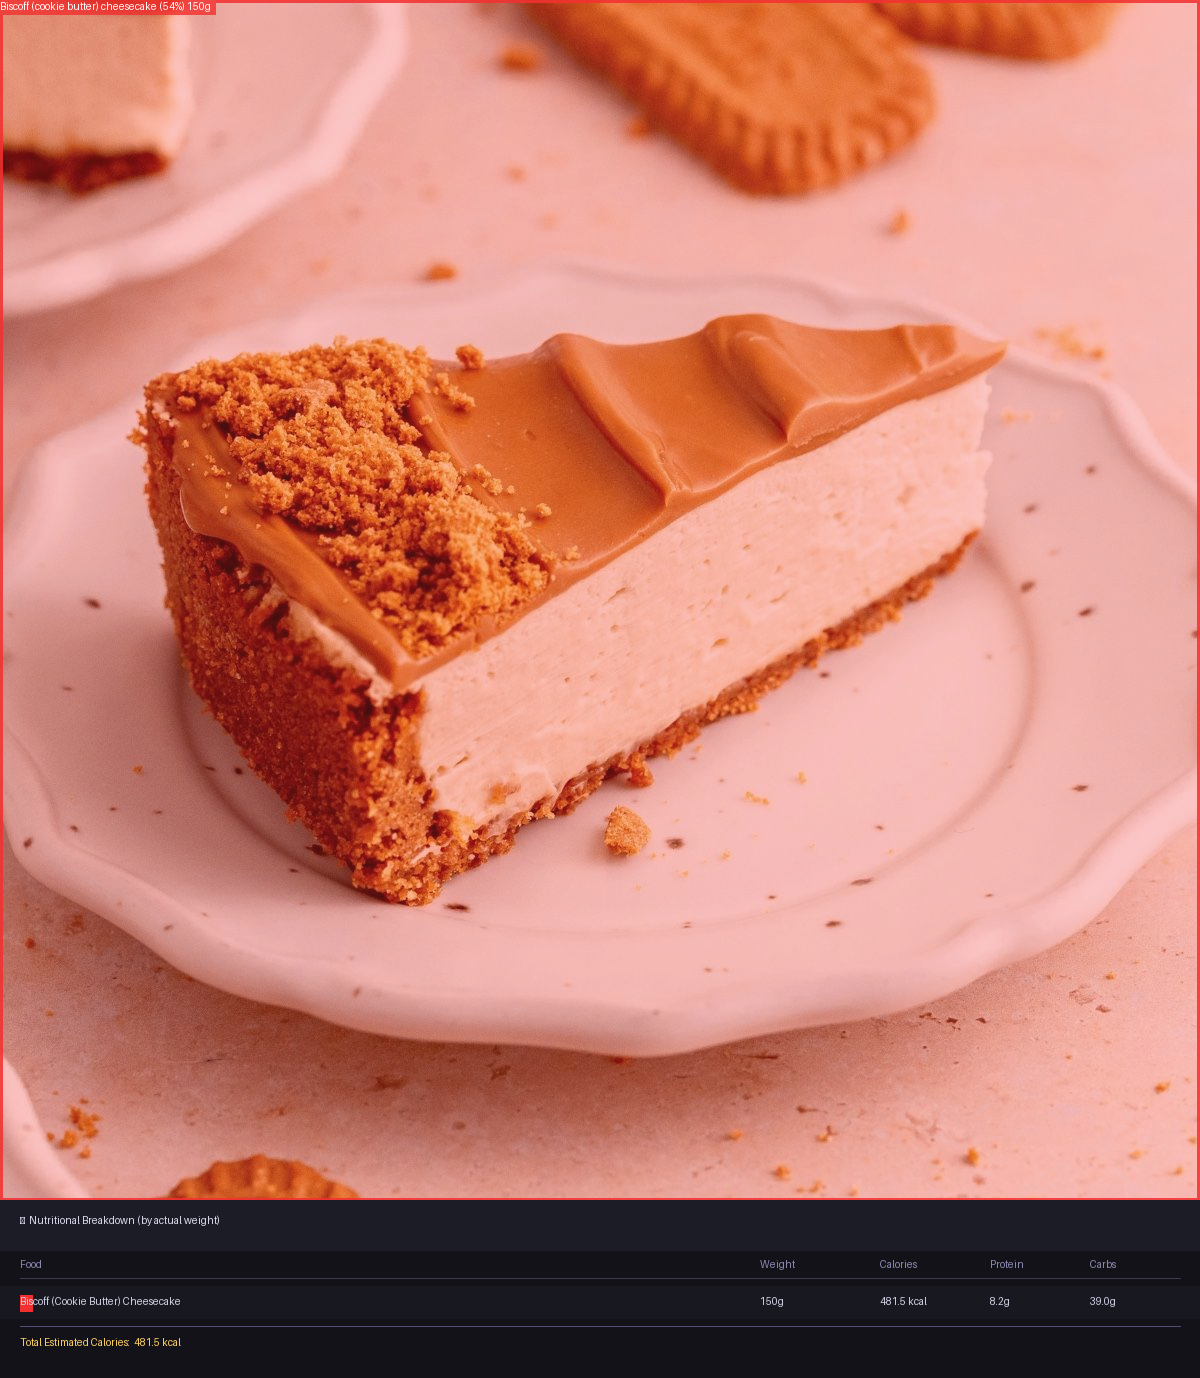

In [36]:
if not segments:
    print('❌ No segments confirmed. Run Cell 7 first.')
else:
    print('🔍 Looking up nutrition data...')
    nutrition_results = {}
    for seg in segments:
        lbl = seg['label']
        if lbl not in nutrition_results:
            info = get_nutrition(lbl)
            nutrition_results[lbl] = info
            cal  = info.get('calories')
            src  = 'builtin' if lbl.replace('_',' ') in ' '.join(BUILTIN.keys()) else 'USDA'
            print(f'   {lbl.replace("_"," "):<30} {str(cal)+" kcal/100g" if cal else "not found"}')

    print('\n🎨 Rendering annotated image...')
    output_image = draw_output(image, segments, nutrition_results)

    OUTPUT_PATH = 'food_analysis_output.jpg'
    output_image.save(OUTPUT_PATH, format='JPEG', quality=92)
    print(f'✅ Saved → {OUTPUT_PATH}')
    display(output_image)

## Cell 9 — Detailed Text Summary

In [29]:
if 'nutrition_results' not in dir() or not segments:
    print('Run Cells 7 and 8 first.')
else:
    merged={}
    for seg in segments:
        lbl=seg['label']
        merged[lbl]=merged.get(lbl,0)+(seg.get('grams') or 0)

    def f(v,u=''): return f'{v:.1f}{u}' if v is not None else '?'

    header = f'{"Food":<28} {"Weight":>8} {"Calories":>11} {"Protein":>9} {"Carbs":>8} {"Fat":>7}'
    print(header)
    print('─'*76)
    total=0.0
    for lbl,grams in merged.items():
        info=nutrition_results.get(lbl,{})
        cv=kcal(info.get('calories'),grams)
        if cv: total+=cv
        print(
            f'{lbl.replace("_"," ").title():<28}'
            f' {f(grams,"g"):>8}'
            f' {f(cv," kcal"):>11}'
            f' {f(kcal(info.get("protein"),grams),"g"):>9}'
            f' {f(kcal(info.get("carbs"),grams),"g"):>8}'
            f' {f(kcal(info.get("fat"),grams),"g"):>7}'
        )
    print('─'*76)
    print(f'{"TOTAL CALORIES":<28} {total:.1f} kcal')

Food                           Weight    Calories   Protein    Carbs     Fat
────────────────────────────────────────────────────────────────────────────
Biscoff (Cookie Butter) Cheesecake   550.0g 1765.5 kcal     30.2g   143.0g  121.0g
────────────────────────────────────────────────────────────────────────────
TOTAL CALORIES               1765.5 kcal
